Simulating J=0.1 ...
  E_kin final = 7.3603
Simulating J=0.25 ...
  E_kin final = 7.3252
Simulating J=0.35 ...
  E_kin final = 7.0448
All done. Plotting ...


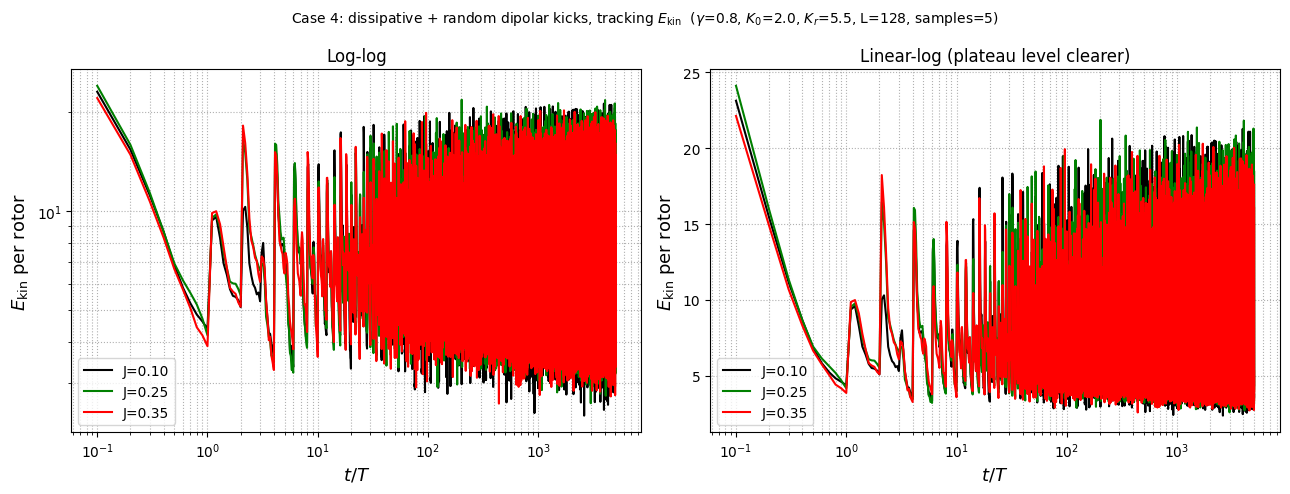

Plot saved.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------
# Here we ask: how does dissipation + random dipolar kicks modify the prethermal E_kin plateau?
# -----------------------------------------------

# Parameters
L         = 128      # chain length
gamma     = 0.8      # damping (1-gamma = dissipation rate); set gamma=1 to recover Rajak
K0        = 2.0      # periodic kick strength
Kr        = 5.5      # random dipolar kick strength
T         = 10       # waiting time between stroboscopic kicks (steps)
J_list    = [0.10, 0.25, 0.35]   # nearest-neighbour interaction strengths
samples   = 5        # ensemble realizations
timesteps = 50000    # total individual steps (= 5000 periods)
                     # increase to 500000 for fuller picture


def simulate_case4(L, gamma, K0, Kr, T, J, timesteps, samples):
    """
    Dissipative 1D kicked rotor chain with random dipolar kicks.
    Tracks E_kin(t) at every timestep.

    Dipolar protocol:
      Kicks come in pairs. Each pair m randomly draws (+Kr,-Kr) or (-Kr,+Kr).
      Kick 1 of pair m is applied at t = 2m*T.
      Kick 2 of pair m is applied at t = (2m+1)*T.
    """
    E_accum = np.zeros(timesteps)

    for s in range(samples):
        theta = np.random.uniform(0, 2 * np.pi, L)
        p     = np.random.normal(0.0, 6.0, L)

        # Pre-draw random signs for each dipolar pair
        # kick_signs[m] = +1 or -1, giving (+Kr,-Kr) or (-Kr,+Kr)
        n_pairs    = timesteps // (2 * T) + 1
        kick_signs = np.random.choice([-1, 1], size=n_pairs)

        for t in range(timesteps):
            period = t // T           # which T-period we are in
            pair   = period // 2      # which dipolar pair this period belongs to

            # Apply random kick at the start of each T-period
            if t % T == 0:
                if period % 2 == 0:
                    # first kick of the pair
                    kr_this = kick_signs[pair] * Kr
                else:
                    # second kick of the pair (opposite sign)
                    kr_this = -kick_signs[pair] * Kr
                p = p + kr_this

            # Deterministic step: damping + onsite kick + interaction
            theta_right = np.roll(theta, -1)   # theta_{i+1}
            theta_left  = np.roll(theta,  1)   # theta_{i-1}
            p = (gamma * p
                 - K0 * np.sin(theta)
                 + J  * (np.sin(theta - theta_right) + np.sin(theta - theta_left)))
            theta = (theta + p) % (2 * np.pi)

            # Kinetic energy per rotor
            E_accum[t] += np.mean(0.5 * p**2)

    return E_accum / samples


# -----------------------------------------------
# Run for each J
# -----------------------------------------------
time_array = np.arange(1, timesteps + 1) / T   # in units of T
results = {}

for J in J_list:
    print(f"Simulating J={J} ...")
    results[J] = simulate_case4(L, gamma, K0, Kr, T, J, timesteps, samples)
    print(f"  E_kin final = {results[J][-500:].mean():.4f}")

print("All done. Plotting ...")

# -----------------------------------------------
# Plot
# -----------------------------------------------
colors = {0.10: "black", 0.25: "green", 0.35: "red"}
labels = {0.10: "J=0.10", 0.25: "J=0.25", 0.35: "J=0.35"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for J in J_list:
    axes[0].plot(time_array, results[J], color=colors[J], label=labels[J])
    axes[1].plot(time_array, results[J], color=colors[J], label=labels[J])

# Left: log-log
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$t/T$", fontsize=13)
axes[0].set_ylabel(r"$E_{\rm kin}$ per rotor", fontsize=13)
axes[0].set_title("Log-log")
axes[0].legend(fontsize=10)
axes[0].grid(True, which="both", ls=":")

# Right: linear-log
axes[1].set_xscale("log")
axes[1].set_yscale("linear")
axes[1].set_xlabel(r"$t/T$", fontsize=13)
axes[1].set_ylabel(r"$E_{\rm kin}$ per rotor", fontsize=13)
axes[1].set_title("Linear-log (plateau level clearer)")
axes[1].legend(fontsize=10)
axes[1].grid(True, which="both", ls=":")

fig.suptitle(
    rf"Case 4: dissipative + random dipolar kicks, tracking $E_{{\rm kin}}$"
    rf"  ($\gamma$={gamma}, $K_0$={K0}, $K_r$={Kr}, L={L}, samples={samples})",
    fontsize=10)

plt.tight_layout()
plt.savefig("case4_ekin_plot.png", dpi=150)
plt.show()
print("Plot saved.")